In [14]:
# notebooks/01_eda_baselines.ipynb

# --- Etapa 1: Entendimento e Preparação ---
# Foco: formulação do problema, exploração de dados e construção de baselines.

# Importar bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score, confusion_matrix, classification_report
import joblib
import logging

In [ ]:
# Importar funções dos módulos src
# Para que o notebook possa encontrar os módulos em src/, precisamos adicionar o caminho ao sys.path
import sys
project_root = Path.cwd().parent # Assumindo que o notebook esta em notebooks/
sys.path.append(str(project_root))

from src.data.make_dataset import load_data, clean_data
from src.features.build_features import split_data, create_preprocessor

# Configurar logging para o notebook (opcional, mas util para acompanhar)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- 1. Carregar e Preparar Dados (usando funções de src/) ---
logging.info("Carregando e preparando dados usando funções de src/...")

# Definir caminhos
raw_data_path = project_root / "data" / "raw" / "telco_customer_churn.csv"
processed_data_path = project_root / "data" / "processed" / "telco_customer_churn_cleaned.csv"
preprocessor_path = project_root / "models" / "preprocessor.joblib"

# Carregar dados brutos (usando função de make_dataset.py)
df_raw = load_data(raw_data_path)
logging.info(f"Dados brutos carregados. Shape: {df_raw.shape}")

# Limpar dados (usando função de make_dataset.py)
df_cleaned = clean_data(df_raw)
logging.info(f"Dados limpos. Shape: {df_cleaned.shape}")

# Salvar o DataFrame limpo (se ainda nao foi salvo pelos scripts)
processed_data_path.parent.mkdir(parents=True, exist_ok=True)
df_cleaned.to_csv(processed_data_path, index=False)
logging.info(f"DataFrame limpo salvo em: {processed_data_path}")

# Separar features (X) e target (y)
X = df_cleaned.drop('Churn', axis=1)
y = df_cleaned['Churn']

# Dividir dados em treino e teste (usando função de build_features.py)
X_train, X_test, y_train, y_test = split_data(df_cleaned)
logging.info(f"Dados divididos: X_train={X_train.shape}, X_test={X_test.shape}")

# Criar e ajustar pre-processador (usando função de build_features.py)
preprocessor = create_preprocessor(X_train)
preprocessor.fit(X_train)
logging.info(f"Pre-processador criado e ajustado.")

# Salvar o preprocessor (se ainda nao foi salvo pelos scripts)
preprocessor_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(preprocessor, preprocessor_path)
logging.info(f"Pre-processador salvo em: {preprocessor_path}")

# Aplicar pre-processamento
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
logging.info(f"Dados pre-processados: X_train_processed={X_train_processed.shape}, X_test_processed={X_test_processed.shape}")


2026-05-07 22:30:03,628 - INFO - Carregando e preparando dados usando funções de src/...
2026-05-07 22:30:03,663 - INFO - {'event': 'data_load_success', 'path': 'c:\\Users\\PlayHard\\Desktop\\ML\\1º ciclo\\Projeto1-PortF\\churn-prediction\\data\\raw\\telco_customer_churn.csv', 'shape': '(7043, 21)', 'encoding': 'utf-8', 'delimiter': ',', 'message': "Dataset carregado com sucesso (encoding: utf-8, delimiter: ',')."}
2026-05-07 22:30:03,664 - INFO - Dados brutos carregados. Shape: (7043, 21)
2026-05-07 22:30:03,667 - INFO - {'event': 'column_drop', 'column': 'customerID', 'message': "Coluna 'customerID' removida."}
2026-05-07 22:30:03,674 - INFO - {'event': 'totalcharges_cleaned', 'message': "Coluna 'TotalCharges' convertida para numerico e nulos preenchidos com 0."}
2026-05-07 22:30:03,676 - INFO - {'event': 'target_encoded', 'message': "Coluna 'Churn' codificada para 0 e 1."}
2026-05-07 22:30:03,684 - INFO - {'event': 'categories_simplified', 'message': "Categorias 'No internet service

2026-05-07 22:30:03,803 - INFO - Iniciando EDA...
2026-05-07 22:30:03,870 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-07 22:30:03,878 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



--- Primeiras 5 linhas do DataFrame limpo ---
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

  MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection  \
0            No             DSL             No          Yes               No   
1            No             DSL            Yes           No              Yes   
2            No             DSL            Yes          Yes               No   
3            No             DSL            Yes           No              Yes   
4            No     Fiber optic             No           No               No   

  TechSupport StreamingTV StreamingMovies        Contract Paper

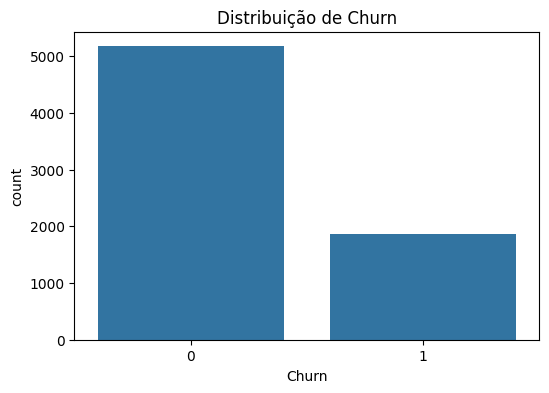

NameError: name 'X' is not defined

In [16]:
# --- 2. Análise Exploratória de Dados (EDA) ---
logging.info("Iniciando EDA...")

# Exibir as primeiras linhas do DataFrame limpo
print("\n--- Primeiras 5 linhas do DataFrame limpo ---")
print(df_cleaned.head())

# Informações gerais sobre o DataFrame
print("\n--- Informações gerais do DataFrame ---")
df_cleaned.info()

# Estatísticas descritivas
print("\n--- Estatísticas descritivas ---")
print(df_cleaned.describe(include='all'))

# Verificação de valores ausentes (deve ser mínimo ou zero após make_dataset.py)
print("\n--- Valores ausentes por coluna ---")
print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

# Distribuição da variável target (Churn)
print("\n--- Distribuição da variável Churn ---")
print(df_cleaned['Churn'].value_counts(normalize=True))
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_cleaned)
plt.title('Distribuição de Churn')
plt.show()

# Distribuição de variáveis numéricas
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()

# Distribuição de variáveis categóricas
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, data=df_cleaned, hue='Churn', palette='viridis')
    plt.title(f'Distribuição de {col} por Churn')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Correlação entre variáveis numéricas
plt.figure(figsize=(12, 10))
sns.heatmap(df_cleaned[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação de Variáveis Numéricas')
plt.show()

logging.info("EDA concluída.")

In [ ]:
# --- 3. Definir Métrica Técnica e de Negócio ---
# Métrica Técnica: AUC-ROC (Area Under the Receiver Operating Characteristic Curve)
# Justificativa: Adequada para problemas de classificação binária com classes desbalanceadas,
# pois avalia a capacidade do modelo de distinguir entre as classes em vários limiares.

# Métrica de Negócio: Custo de Churn Evitado
# Para calcular, precisamos de:
# - Custo médio de aquisição de um novo cliente (CAC)
# - Receita média gerada por um cliente (LTV - Lifetime Value)
# - Custo de uma intervenção para evitar churn
# Exemplo hipotético:
CAC = 200  # Custo para adquirir um novo cliente
LTV_churned = 500 # Receita perdida se o cliente da churn
Custo_intervencao = 50 # Custo de uma campanha ou oferta para evitar churn

# O custo de churn evitado seria (LTV_churned - Custo_intervencao) por cliente que seria churn e foi salvo.
# Ou, de forma mais simples, a receita que seria perdida e foi mantida.
# Para o baseline, vamos focar na métrica técnica primeiro.

# --- 4. Treinar Baselines com MLflow ---
logging.info("Iniciando treinamento de baselines com MLflow...")

# Configurar MLflow (se nao estiver configurado globalmente)
# mlflow.set_tracking_uri("http://localhost:5000") # Se estiver rodando um servidor MLflow local
mlflow.set_experiment("Churn_Prediction_Baselines")

In [ ]:
# --- Baseline 1: DummyClassifier ---
with mlflow.start_run(run_name="DummyClassifier_Baseline"):
    mlflow.log_param("model_type", "DummyClassifier")
    mlflow.log_param("strategy", "stratified") # Estratégia padrão para classes desbalanceadas

    dummy_model = DummyClassifier(strategy="stratified", random_state=42)
    dummy_model.fit(X_train_processed, y_train)
    y_pred_dummy = dummy_model.predict(X_test_processed)
    y_proba_dummy = dummy_model.predict_proba(X_test_processed)[:, 1]

    # Calcular métricas
    auc_roc_dummy = roc_auc_score(y_test, y_proba_dummy)
    f1_dummy = f1_score(y_test, y_pred_dummy)
    precision_dummy, recall_dummy, _ = precision_recall_curve(y_test, y_proba_dummy)
    pr_auc_dummy = auc(recall_dummy, precision_dummy)

    logging.info(f"DummyClassifier - AUC-ROC: {auc_roc_dummy:.4f}, F1-Score: {f1_dummy:.4f}, PR-AUC: {pr_auc_dummy:.4f}")

    # Registrar métricas no MLflow
    mlflow.log_metric("auc_roc", auc_roc_dummy)
    mlflow.log_metric("f1_score", f1_dummy)
    mlflow.log_metric("pr_auc", pr_auc_dummy)

    # Registrar o modelo (opcional para baselines simples, mas boa pratica)
    mlflow.sklearn.log_model(dummy_model, "dummy_model")

    # Registrar o dataset version (simplesmente o caminho do arquivo processado)
    mlflow.log_param("dataset_version", str(processed_data_path))

    # Relatório de classificação
    print("\n--- DummyClassifier Classification Report ---")
    print(classification_report(y_test, y_pred_dummy))

In [ ]:
# --- Baseline 2: Regressão Logística ---
with mlflow.start_run(run_name="LogisticRegression_Baseline"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("solver", "liblinear") # Um solver robusto para datasets pequenos
    mlflow.log_param("random_state", 42)

    lr_model = LogisticRegression(solver='liblinear', random_state=42)
    lr_model.fit(X_train_processed, y_train)
    y_pred_lr = lr_model.predict(X_test_processed)
    y_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]

    # Calcular métricas
    auc_roc_lr = roc_auc_score(y_test, y_proba_lr)
    f1_lr = f1_score(y_test, y_pred_lr)
    precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
    pr_auc_lr = auc(recall_lr, precision_lr)

    logging.info(f"LogisticRegression - AUC-ROC: {auc_roc_lr:.4f}, F1-Score: {f1_lr:.4f}, PR-AUC: {pr_auc_lr:.4f}")

    # Registrar métricas no MLflow
    mlflow.log_metric("auc_roc", auc_roc_lr)
    mlflow.log_metric("f1_score", f1_lr)
    mlflow.log_metric("pr_auc", pr_auc_lr)

    # Registrar o modelo
    mlflow.sklearn.log_model(lr_model, "logistic_regression_model")

    # Registrar o dataset version
    mlflow.log_param("dataset_version", str(processed_data_path))

    # Relatório de classificação
    print("\n--- Logistic Regression Classification Report ---")
    print(classification_report(y_test, y_pred_lr))

logging.info("Treinamento de baselines concluído e experimentos registrados no MLflow.")
